In [ ]:
Lecture 5 — Class Exercise
Distribution Charts: Airbnb London
Push to: week05/lecture05_exercise.ipynb

Rules:

Cap price outliers at 95th percentile — annotate this
Every chart has a median/mean reference line with annotation
Insight title names the distribution shape or key finding
Colour has meaning — don't use colour just for decoration

In [2]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Airbnb London Listings

df = pd.read_csv('airbnb_london.csv')
print(f"Loaded: {len(df)} listings")
print(df.describe().round(1))

Loaded: 2500 listings
        price  minimum_nights  number_of_reviews  availability_365  \
count  2500.0          2500.0             2500.0            2500.0   
mean    148.6            14.8              147.9             183.7   
std     110.9             8.4               86.3             105.5   
min      20.5             1.0                0.0               0.0   
25%      71.7             8.0               74.0              92.0   
50%     117.5            15.0              145.0             182.0   
75%     188.9            22.0              222.2             277.0   
max    1032.4            29.0              299.0             364.0   

       reviews_per_month  
count             2500.0  
mean                 2.0  
std                  2.0  
min                  0.0  
25%                  0.6  
50%                  1.4  
75%                  2.8  
max                 15.2  


In [4]:
p95 = df['price'].quantile(0.95)
df_cap = df[df['price'] <= p95]
print(f"95th percentile price: £{p95:.0f}")
print(df_cap.groupby('room_type')['price'].describe().round(1))

95th percentile price: £373
                  count   mean   std   min    25%    50%    75%    max
room_type                                                             
Entire home/apt  1251.0  176.3  75.7  28.0  119.6  163.4  223.5  372.6
Private room      942.0   87.3  39.5  20.9   59.0   78.6  106.0  277.9
Shared room       182.0   46.3  14.1  20.5   36.8   44.1   54.3   92.8


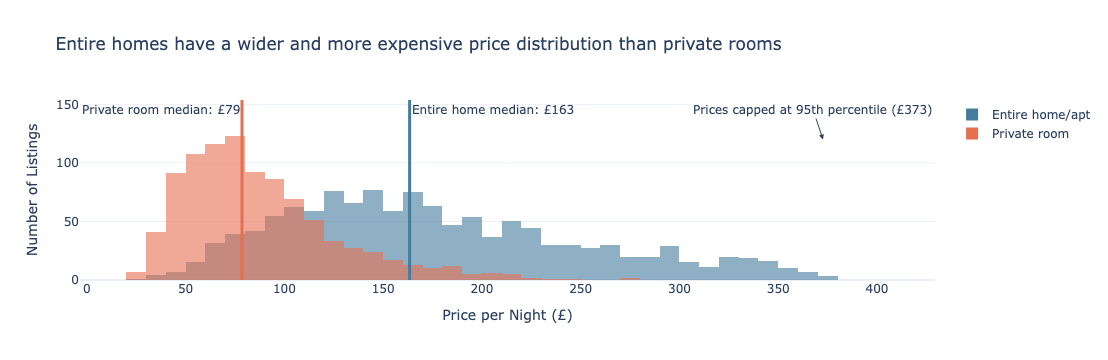

In [7]:

task1_df = df_cap[
    df_cap['room_type'].isin(['Entire home/apt', 'Private room'])
]


median_entire = task1_df.loc[
    task1_df['room_type'] == 'Entire home/apt',
    'price'
].median()

median_private = task1_df.loc[
    task1_df['room_type'] == 'Private room',
    'price'
].median()


fig1 = px.histogram(
    task1_df,
    x='price',
    color='room_type',
    barmode='overlay',
    opacity=0.6,
    nbins=40,
    title='Entire homes have a wider and more expensive price distribution than private rooms',
    color_discrete_map={
        'Entire home/apt': '#457B9D',
        'Private room': '#E76F51'
    }
)


fig1.add_vline(
    x=median_entire,
    line_color='#457B9D',
    line_width=3,
    annotation_text=f'Entire home median: £{median_entire:.0f}',
    annotation_position='top right'
)

fig1.add_vline(
    x=median_private,
    line_color='#E76F51',
    line_width=3,
    annotation_text=f'Private room median: £{median_private:.0f}',
    annotation_position='top left'
)


fig1.add_annotation(
    x=p95,
    y=120,
    text=f'Prices capped at 95th percentile (£{p95:.0f})',
    showarrow=True,
    arrowhead=2,
    bgcolor='white'
)


fig1.update_layout(
    template='plotly_white',
    xaxis_title='Price per Night (£)',
    yaxis_title='Number of Listings',
    legend_title=''
)

fig1.show()

p95 = df['price'].quantile(0.95)


df_cap = df[df['price'] <= p95]

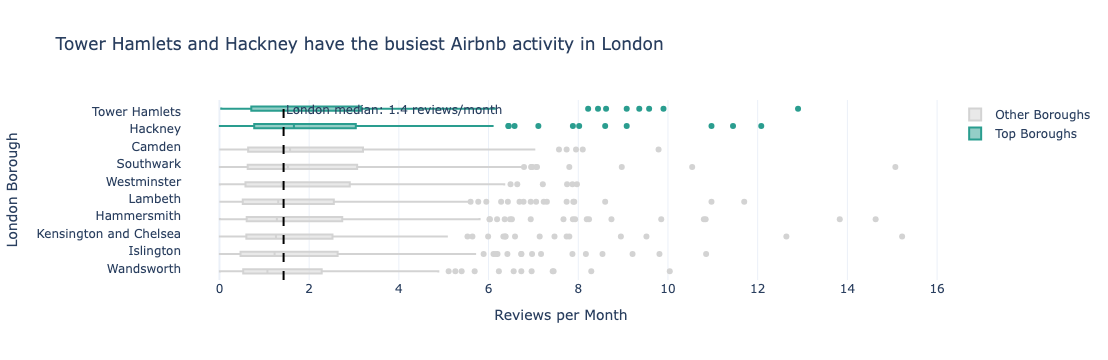

In [13]:
import pandas as pd
import plotly.express as px
import numpy as np

df = pd.read_csv('airbnb_london.csv')

task2_df = df[df['reviews_per_month'] > 0].copy()

borough_order = (
    task2_df.groupby('neighbourhood')['reviews_per_month']
    .median()
    .sort_values(ascending=False)
)

top_two = borough_order.head(2).index.tolist()

task2_df['highlight'] = task2_df['neighbourhood'].apply(
    lambda x: 'Top Boroughs' if x in top_two else 'Other Boroughs'
)

fig2 = px.box(
    task2_df,
    x='reviews_per_month',
    y='neighbourhood',
    color='highlight',
    orientation='h',
    points='outliers',
    category_orders={
        'neighbourhood': borough_order.index.tolist()
    },
    title=f'{top_two[0]} and {top_two[1]} have the busiest Airbnb activity in London',
    color_discrete_map={
        'Top Boroughs': '#2A9D8F',
        'Other Boroughs': '#D3D3D3'
    }
)

global_median = task2_df['reviews_per_month'].median()

fig2.add_vline(
    x=global_median,
    line_dash='dash',
    line_color='black',
    annotation_text=f'London median: {global_median:.1f} reviews/month',
    annotation_position='top right'
)

fig2.update_layout(
    template='plotly_white',
    xaxis_title='Reviews per Month',
    yaxis_title='London Borough',
    legend_title=''
)

fig2.show()